In [1]:
import sys
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import math
import numpy as np
import matplotlib.pyplot as plt

import vmc

In [2]:
rng = np.random.default_rng(1)
worst_energy = worst_force = 0.0
for omega in (0.5, 1.0, 2.0):
    for _ in range(15):
        r = rng.normal(0.0, 1.0, (2, 2))
        for alpha, beta in ((0.98, 0.40), (0.80, 0.20), (1.10, 0.60)):
            worst_energy = max(worst_energy,
                abs(vmc.local_energy(r, alpha, beta, omega)
                    - vmc.local_energy_fd(r, alpha, beta, omega)))
            worst_force = max(worst_force, float(np.abs(
                vmc.quantum_force(r, alpha, beta, omega)
                - vmc.quantum_force_fd(r, alpha, beta, omega)).max()))
print(f"local energy : largest discrepancy {worst_energy:.1e}")
print(f"quantum force: largest discrepancy {worst_force:.1e}")
print("(both at the level of the finite-difference truncation error)")

local energy : largest discrepancy 5.1e-05
quantum force: largest discrepancy 2.7e-10
(both at the level of the finite-difference truncation error)


     r_12   E_L with Jastrow    E_L without
   1.0000           3.031237           3.00
   0.1000           2.703286          12.00
   0.0100           2.611464         102.00
   0.0010           2.601159        1002.00
   0.0001           2.600116       10002.00


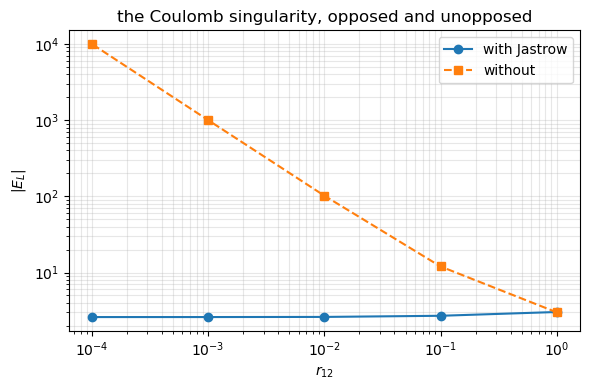

In [3]:
separations = np.array([1.0, 0.1, 0.01, 0.001, 0.0001])
with_jastrow, without = [], []
for r12 in separations:
    r = np.array([[r12/2, 0.0], [-r12/2, 0.0]])
    with_jastrow.append(vmc.local_energy(r, 1.0, 0.4))
    without.append(2.0 + 1.0/r12)

print(f"{'r_12':>9s} {'E_L with Jastrow':>18s} {'E_L without':>14s}")
for r12, a, b in zip(separations, with_jastrow, without):
    print(f"{r12:9.4f} {a:18.6f} {b:14.2f}")

plt.figure(figsize=(6, 4))
plt.loglog(separations, np.abs(with_jastrow), "o-", label="with Jastrow")
plt.loglog(separations, without, "s--", label="without")
plt.xlabel("$r_{12}$"); plt.ylabel("$|E_L|$")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.title("the Coulomb singularity, opposed and unopposed")
plt.tight_layout(); plt.show()

In [4]:
steps = (0.5, 1.0, 2.0, 4.0, 8.0)
brute = {}
print(f"{'step':>6s} {'acceptance':>11s} {'energy':>13s} {'error':>10s} "
      f"{'variance':>10s} {'tau':>7s}")
for step in steps:
    r = vmc.vmc_brute_force(0.98, 0.40, n_cycles=20000, step=step,
                            rng=np.random.default_rng(2024))
    brute[step] = r
    print(f"{step:6.1f} {r['acceptance']:10.1%} {r['energy']:13.6f} "
          f"{r['error']:10.6f} {r['variance']:10.5f} {r['tau']:7.2f}")

  step  acceptance        energy      error   variance     tau


   0.5      90.2%      2.999367   0.001400    0.00186   21.06


   1.0      80.2%      2.999729   0.000756    0.00197    5.79


   2.0      62.2%      3.000874   0.000503    0.00185    2.74


   4.0      35.2%      2.999744   0.000456    0.00190    2.18


   8.0      11.6%      3.000497   0.000811    0.00179    7.35


In [5]:
time_steps = (0.01, 0.05, 0.1, 0.3, 0.5, 1.0)
importance = {}
print(f"{'dt':>7s} {'acceptance':>11s} {'energy':>13s} {'error':>10s} "
      f"{'variance':>10s} {'tau':>7s}")
for dt in time_steps:
    r = vmc.vmc_importance(0.98, 0.40, n_cycles=20000, time_step=dt,
                           rng=np.random.default_rng(2024))
    importance[dt] = r
    print(f"{dt:7.3f} {r['acceptance']:10.1%} {r['energy']:13.6f} "
          f"{r['error']:10.6f} {r['variance']:10.5f} {r['tau']:7.2f}")

     dt  acceptance        energy      error   variance     tau


  0.010     100.0%      3.002679   0.002268    0.00207   49.72


  0.050      99.5%      3.002015   0.000914    0.00196    8.52


  0.100      98.7%      3.001107   0.000721    0.00204    5.09


  0.300      93.9%      3.000415   0.000393    0.00197    1.57


  0.500      87.7%      3.000438   0.000348    0.00195    1.24


  1.000      69.6%      3.001128   0.000323    0.00181    1.15


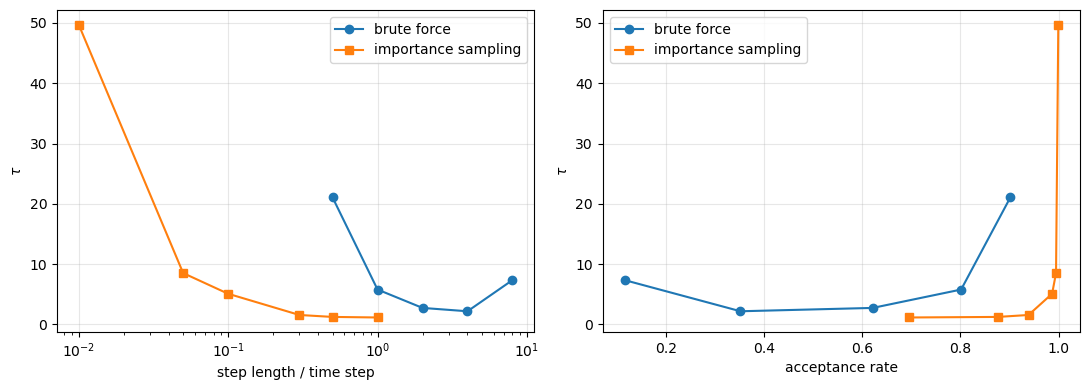

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(steps, [brute[s]["tau"] for s in steps], "o-",
                 label="brute force")
axes[0].semilogx(time_steps, [importance[d]["tau"] for d in time_steps], "s-",
                 label="importance sampling")
axes[0].set_xlabel("step length / time step"); axes[0].set_ylabel(r"$\tau$")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([brute[s]["acceptance"] for s in steps],
             [brute[s]["tau"] for s in steps], "o-", label="brute force")
axes[1].plot([importance[d]["acceptance"] for d in time_steps],
             [importance[d]["tau"] for d in time_steps], "s-",
             label="importance sampling")
axes[1].set_xlabel("acceptance rate"); axes[1].set_ylabel(r"$\tau$")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
b = vmc.vmc_brute_force(0.98, 0.40, n_cycles=40000, step=4.0,
                        rng=np.random.default_rng(7))
i = vmc.vmc_importance(0.98, 0.40, n_cycles=40000, time_step=0.5,
                       rng=np.random.default_rng(7))
print(f"{'sampler':>22s} {'acceptance':>11s} {'energy':>13s} {'error':>10s} "
      f"{'tau':>7s} {'n_eff':>8s}")
for label, r in (("brute force", b), ("importance sampling", i)):
    print(f"{label:>22s} {r['acceptance']:10.1%} {r['energy']:13.6f} "
          f"{r['error']:10.6f} {r['tau']:7.2f} "
          f"{len(r['samples'])/r['tau']:8.0f}")
ratio = b["error"]/i["error"]
print(f"\nerror ratio {ratio:.2f}, a factor {ratio**2:.1f} in computer time")
print("A real but unspectacular gain — for a system this small with a very")
print("good trial function, brute force is already close to optimal.  The")
print("advantage grows with particle number, and becomes essential in DMC.")

               sampler  acceptance        energy      error     tau    n_eff
           brute force      35.2%      3.000889   0.000322    2.28    17531
   importance sampling      87.5%      3.000406   0.000245    1.23    32521

error ratio 1.31, a factor 1.7 in computer time
A real but unspectacular gain — for a system this small with a very
good trial function, brute force is already close to optimal.  The
advantage grows with particle number, and becomes essential in DMC.


In [8]:
print(f"{'quantum force':>22s} {'acceptance':>11s} {'energy':>13s} "
      f"{'error':>10s} {'tau':>7s}")
for label, f in (("correct", vmc.quantum_force),
                 ("terms multiplied", vmc.wrong_quantum_force)):
    r = vmc.vmc_importance(0.98, 0.40, n_cycles=20000, time_step=0.5,
                           rng=np.random.default_rng(11), force=f)
    print(f"{label:>22s} {r['acceptance']:10.1%} {r['energy']:13.6f} "
          f"{r['error']:10.6f} {r['tau']:7.2f}")
print("\nBoth energies are right.  A wrong *local energy*, by contrast,")
print("would give a wrong number — which is why both are checked against")
print("finite differences in section 1.")

         quantum force  acceptance        energy      error     tau


               correct      87.5%      3.000019   0.000343    1.20


      terms multiplied      57.2%      3.000196   0.000491    2.59

Both energies are right.  A wrong *local energy*, by contrast,
would give a wrong number — which is why both are checked against
finite differences in section 1.


energy
            0.30      0.36      0.40      0.44      0.50   <- beta
 0.94   3.01812   3.00798   3.00500   3.00344   3.00383
 0.96   3.01208   3.00402   3.00226   3.00161   3.00303
 0.98   3.00777   3.00147   3.00061   3.00102   3.00349
 1.00   3.00427   3.00019   3.00015   3.00167   3.00487
 1.02   3.00204   3.00014   3.00120   3.00344   3.00699

variance
            0.30      0.36      0.40      0.44      0.50   <- beta
 0.94   0.03217   0.01418   0.00775   0.00479   0.00556
 0.96   0.02423   0.00858   0.00372   0.00229   0.00496
 0.98   0.01786   0.00518   0.00190   0.00191   0.00637
 1.00   0.01384   0.00378   0.00216   0.00350   0.00974
 1.02   0.01187   0.00441   0.00426   0.00688   0.01489


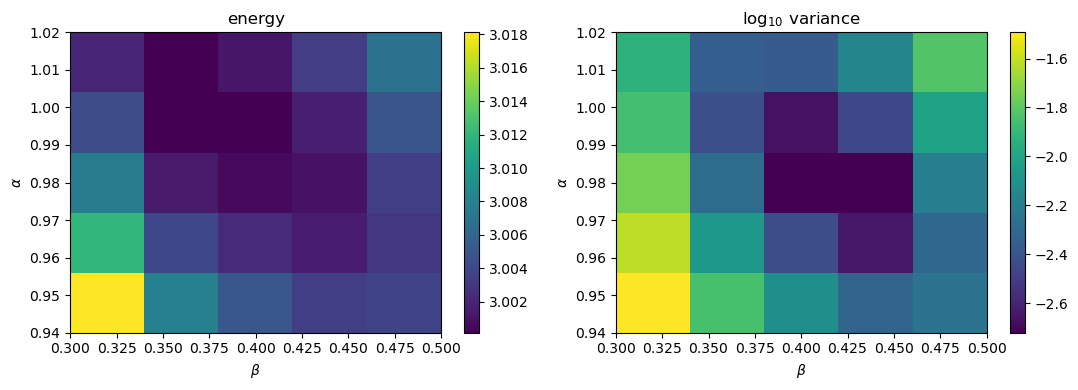

In [9]:
alphas = np.array([0.94, 0.96, 0.98, 1.00, 1.02])
betas = np.array([0.30, 0.36, 0.40, 0.44, 0.50])
energies, variances, errors = vmc.scan(alphas, betas, n_cycles=8000,
                                       time_step=0.5)

print("energy")
print("      " + "".join(f"{b:>10.2f}" for b in betas) + "   <- beta")
for i_, a in enumerate(alphas):
    print(f"{a:5.2f}" + "".join(f"{energies[i_, j]:10.5f}"
                                for j in range(len(betas))))
print("\nvariance")
print("      " + "".join(f"{b:>10.2f}" for b in betas) + "   <- beta")
for i_, a in enumerate(alphas):
    print(f"{a:5.2f}" + "".join(f"{variances[i_, j]:10.5f}"
                                for j in range(len(betas))))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, name in ((axes[0], energies, "energy"),
                       (axes[1], np.log10(variances), "log$_{10}$ variance")):
    im = ax.imshow(data, origin="lower", aspect="auto", cmap="viridis",
                   extent=[betas[0], betas[-1], alphas[0], alphas[-1]])
    ax.set_xlabel(r"$\beta$"); ax.set_ylabel(r"$\alpha$"); ax.set_title(name)
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

In [10]:
best = vmc.vmc_importance(1.00, 0.38, n_cycles=120000, time_step=0.5,
                          rng=np.random.default_rng(2024))
print(f"VMC, importance sampling, 120 000 cycles, alpha = 1, beta = 0.38")
print(f"   E = {best['energy']:.6f} +/- {best['error']:.6f}"
      f"   (variance {best['variance']:.5f}, tau {best['tau']:.2f})")
print()
print(f"   exact (Taut)              {vmc.TAUT_ENERGY:.6f}")
print( "   CCSD, 42 orbitals         3.013626      (table 11.4)")
print( "   Hartree-Fock, 42 orbitals 3.161921      (table 11.3)")
gap = best["energy"] - vmc.TAUT_ENERGY
print()
print(f"gap to the exact answer: {gap:.6f} = {gap/best['error']:.0f} standard errors")
print(f"CCSD error / VMC error : {0.013626/gap:.0f}")

VMC, importance sampling, 120 000 cycles, alpha = 1, beta = 0.38
   E = 3.000446 +/- 0.000156   (variance 0.00260, tau 1.12)

   exact (Taut)              3.000000
   CCSD, 42 orbitals         3.013626      (table 11.4)
   Hartree-Fock, 42 orbitals 3.161921      (table 11.3)

gap to the exact answer: 0.000446 = 3 standard errors
CCSD error / VMC error : 31
